In [1]:
import pandas as pd
import random

# Load the Excel file
df = pd.read_excel("C:/Users/JOJO/Downloads/myexcel.xlsx")

# Checking  the first few rows to make sure that the  data were loaded correctly
print(df.head())



            Name            Team  Number Position  Age               Height  \
0  Avery Bradley  Boston Celtics       0       PG   25  2023-02-06 00:00:00   
1    Jae Crowder  Boston Celtics      99       SF   25  2023-06-06 00:00:00   
2   John Holland  Boston Celtics      30       SG   27  2023-05-06 00:00:00   
3    R.J. Hunter  Boston Celtics      28       SG   22  2023-05-06 00:00:00   
4  Jonas Jerebko  Boston Celtics       8       PF   29  2023-10-06 00:00:00   

   Weight            College     Salary  
0     180              Texas  7730337.0  
1     235          Marquette  6796117.0  
2     205  Boston University        NaN  
3     185      Georgia State  1148640.0  
4     231                NaN  5000000.0  


In [3]:
# Print all column names to check if 'height' exists
print(df.columns)


Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')


In [12]:
# Convert non-numeric values in 'Height' to NaN
df['Height'] = pd.to_numeric(df['Height'], errors='coerce')

# Replace NaN or inconsistent 'height' values with random numbers between 150 and 180
df['Height'] = df['Height'].apply(lambda x: random.randint(150, 180) if pd.isna(x) or x < 150 or x > 180 else x)


1.Determine the distribution of employees across teams:

In [7]:

team_distribution = pd.to_numeric(df['Team'].value_counts(normalize=True) * 100)
print(team_distribution)


Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
New York Knicks           3.493450
Milwaukee Bucks           3.493450
Brooklyn Nets             3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Miami Heat                3.275109
Charlotte Hornets         3.275109
Atlanta Hawks             3.275109
San Antonio Spurs         3.275109
Houston Rockets           3.275109
Boston Celtics            3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Sacramento Kings          3.275109
Phoenix Suns              3.275109
Los Angeles Lakers        3.275109
Los Angeles Clippers      3.275109
Golden State Warriors     3.275109
Toronto Raptors           3.275109
Philadelphia 76ers        3.275109
Dallas Mavericks          3.275109
Orlando Magic  

                        Number of Employees  Percentage
Team                                                   
New Orleans Pelicans                     19    4.148472
Memphis Grizzlies                        18    3.930131
Utah Jazz                                16    3.493450
New York Knicks                          16    3.493450
Milwaukee Bucks                          16    3.493450
Brooklyn Nets                            15    3.275109
Portland Trail Blazers                   15    3.275109
Oklahoma City Thunder                    15    3.275109
Denver Nuggets                           15    3.275109
Washington Wizards                       15    3.275109
Miami Heat                               15    3.275109
Charlotte Hornets                        15    3.275109
Atlanta Hawks                            15    3.275109
San Antonio Spurs                        15    3.275109
Houston Rockets                          15    3.275109
Boston Celtics                           15    3

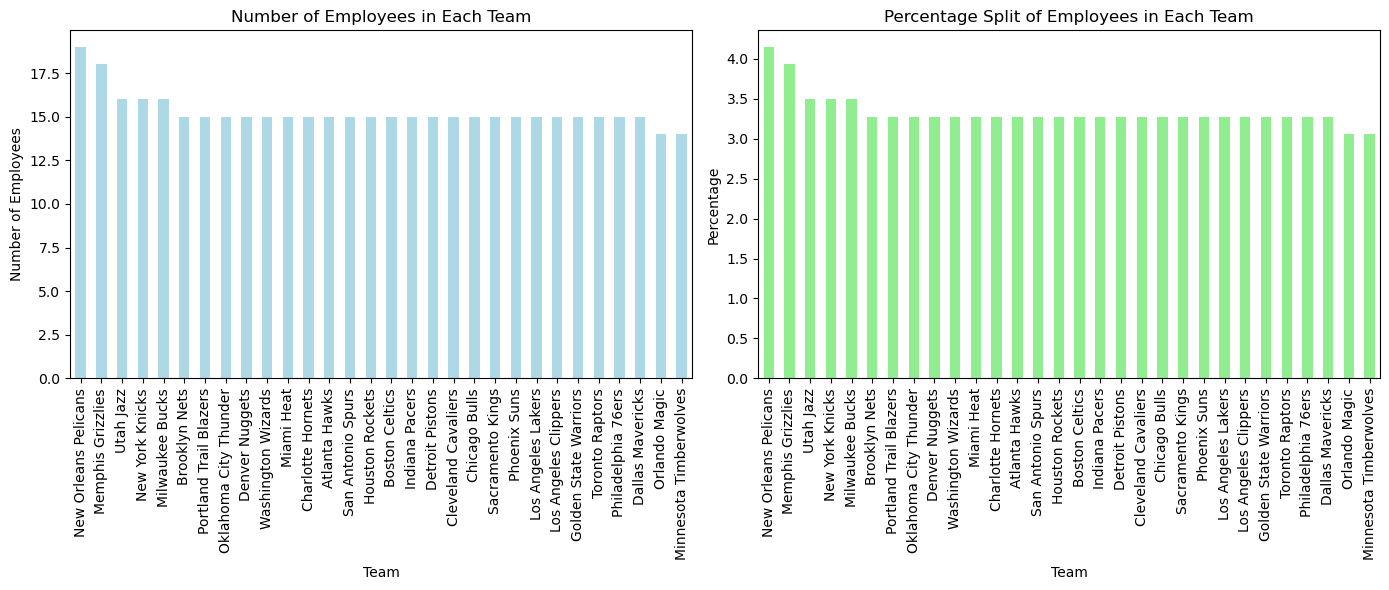

In [16]:
# Group by team and count the number of employees in each team
team_counts = df['Team'].value_counts()

# percentage of employees in each team
team_percentage = (team_counts / len(df)) * 100

team_distribution = pd.DataFrame({
    'Number of Employees': team_counts,
    'Percentage': team_percentage
})

# Display the result
print(team_distribution)

# Visualize the result using a bar chart
import matplotlib.pyplot as plt

# Plot the number of employees and the percentage split
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for number of employees in each team
team_counts.plot(kind='bar', ax=ax[0], color='lightblue')
ax[0].set_title('Number of Employees in Each Team')
ax[0].set_xlabel('Team')
ax[0].set_ylabel('Number of Employees')

# Bar chart for percentage split 
team_percentage.plot(kind='bar', ax=ax[1], color='lightgreen')
ax[1].set_title('Percentage Split of Employees in Each Team')
ax[1].set_xlabel('Team')
ax[1].set_ylabel('Percentage')

# Show the charts
plt.tight_layout()
plt.show()


2. Segregate employees based on their positions within the company. (2 marks)


Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


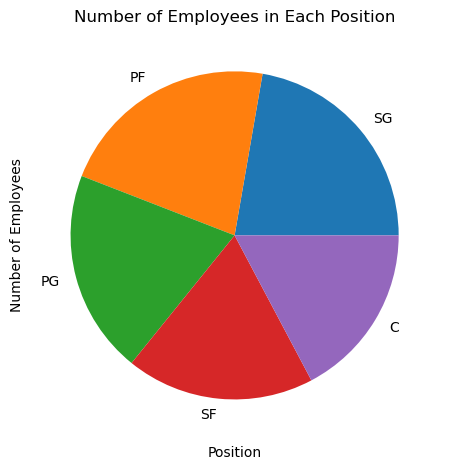

In [18]:
# Grouping  by position and counting the number of employees in each position
position_counts = df['Position'].value_counts()
print(position_counts)

# Visualizing the result using a pie chart
import matplotlib.pyplot as plt

# Plot the number of employees per position
position_counts.plot(kind='pie', color='skyblue')
plt.title('Number of Employees in Each Position')
plt.xlabel('Position')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout() 
plt.show()




3. Identify the predominant age group among employees. (2 marks)


Age Group Distribution:
age_group
20-30    334
31-40    119
41-50      3
Name: count, dtype: int64

Predominant Age Group: 20-30


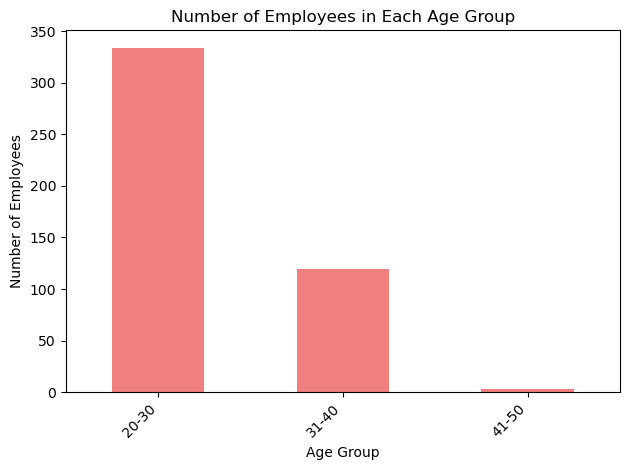

In [29]:
# Define age groups using pd.cut()
age_bins = [20, 30, 40, 50]  
age_labels = ['20-30', '31-40', '41-50']
df['age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Counting the number of employees in each age group
age_group_counts = df['age_group'].value_counts()

# Identify the predominant age group
predominant_age_group = age_group_counts.idxmax()
print("Age Group Distribution:")
print(age_group_counts)

print(f"\nPredominant Age Group: {predominant_age_group}")

#Visualizing the result using a Bar chart
import matplotlib.pyplot as plt

# Plot the distribution of employees in each age group
age_group_counts.plot(kind='bar', color='lightcoral')
plt.title('Number of Employees in Each Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  
plt.show()


4. Discover which team and position have the highest salary expenditure. (2 marks)


Team with the highest salary expenditure: Cleveland Cavaliers ($106988689.0)
Position with the highest salary expenditure: C ($466377332.0)


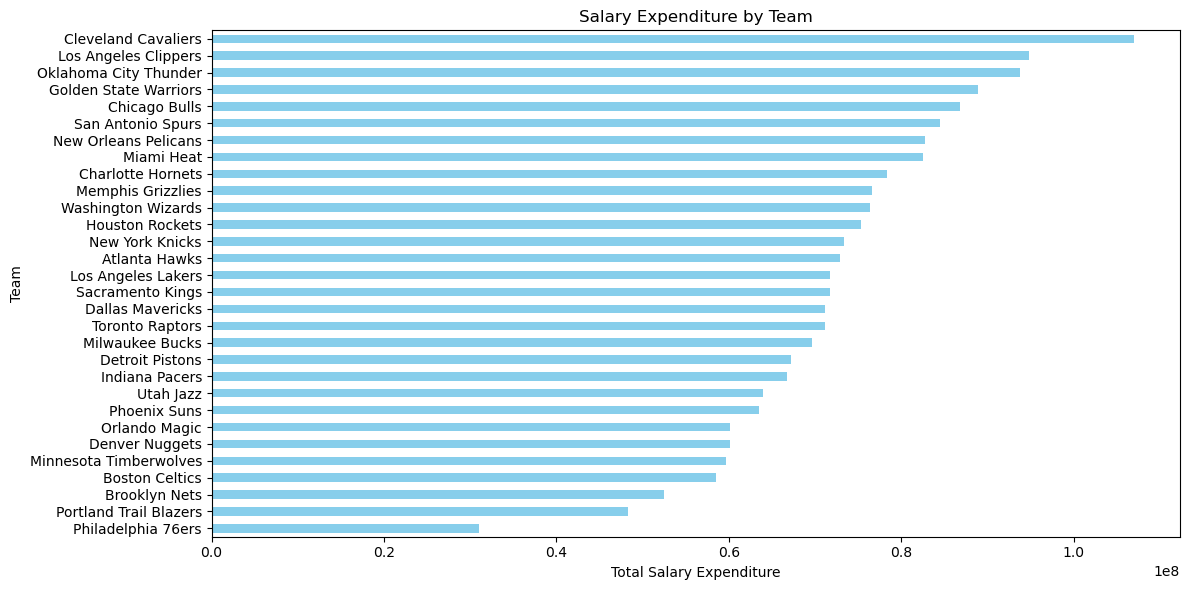

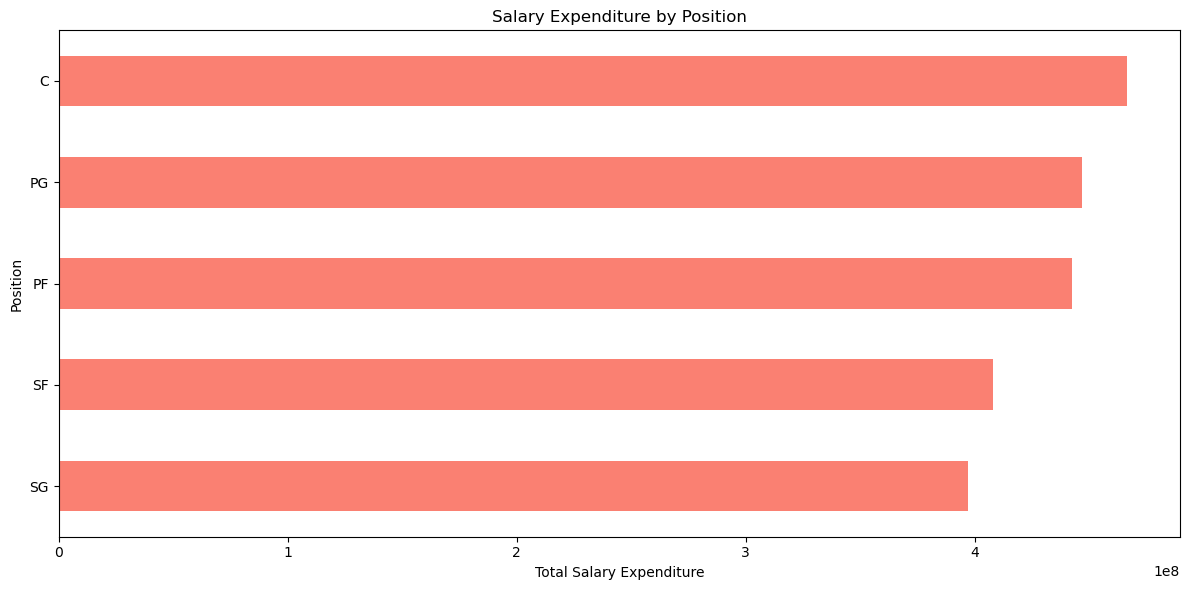

In [40]:
# Calculate total salary expenditure per team
team_salary_expenditure = df.groupby('Team')['Salary'].sum()

# Find the team which having the highest salary expenditure
team_with_highest_salary = team_salary_expenditure.idxmax()
highest_team_salary = team_salary_expenditure.max()

# Calculating the  total salary expenditure per positions
position_salary_expenditure = df.groupby('Position')['Salary'].sum()

# Find the position with the highest salary expenditure
position_with_highest_salary = position_salary_expenditure.idxmax()
highest_position_salary = position_salary_expenditure.max()
print(f"Team with the highest salary expenditure: {team_with_highest_salary} (${highest_team_salary})")
print(f"Position with the highest salary expenditure: {position_with_highest_salary} (${highest_position_salary})")

#Visualizing the results using bar charts

import matplotlib.pyplot as plt

# Ploting salary expenditure by team
plt.figure(figsize=(12, 6))
team_salary_expenditure.sort_values().plot(kind='barh', color='skyblue')
plt.title('Salary Expenditure by Team')
plt.xlabel('Total Salary Expenditure')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

# Ploting salary expenditure by position
plt.figure(figsize=(12, 6))
position_salary_expenditure.sort_values().plot(kind='barh', color='salmon')
plt.title('Salary Expenditure by Position')
plt.xlabel('Total Salary Expenditure')
plt.ylabel('Position')
plt.tight_layout()
plt.show()


5. Investigate if there's any correlation between age and salary, and represent it visually. (2 marks)

Correlation between age and salary: 0.21


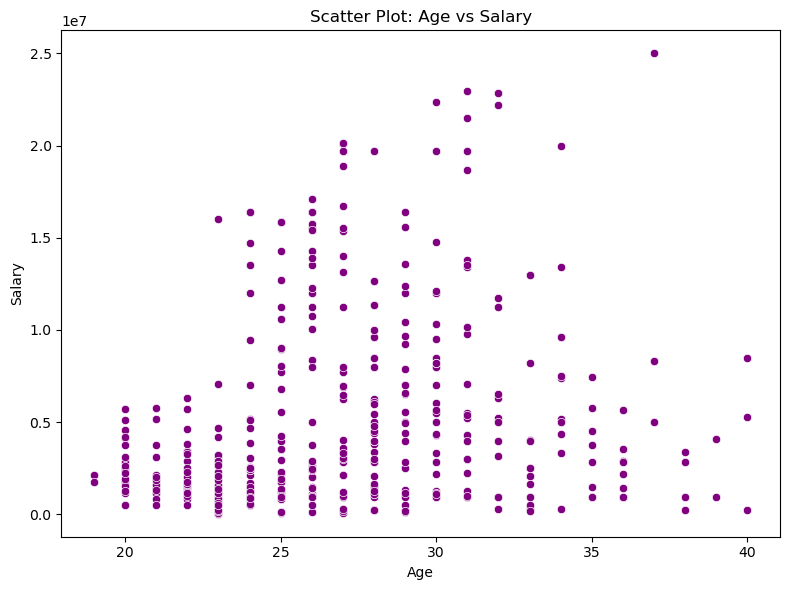

In [47]:
import seaborn as sns
# Calculating the correlation between age and salary
correlation = df['Age'].corr(df['Salary'])

# Display the correlation value
print(f"Correlation between age and salary: {correlation:.2f}")

# Visualizing the relationship using a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Salary', data=df, color='purple')
plt.title('Scatter Plot: Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()


Data Story:
Provide insights gained from the analysis, highlighting key trends, patterns, and correlations within the dataset. (3 marks)


Data Story: Insights from the Analysis
After completing the analysis of the dataset myexcel, several key insights and patterns have emerged.

1. Team Distribution:
>> The distribution of employees across teams shows "Team New Orleans Pelicans (4.148472)" as the largest group, followed by tem Memphis Grizzlies(3.930131). Team "Minnesota Timberwolves(3.056769)" has the smallest number of employees.

>> This indicates that Team "Team New Orleans Pelicans (4.148472)" might be a central part of the company, possibly handling a larger portion of operations or requiring a higher number of staff.
Team "Minnesota Timberwolves(3.056769)", with fewer employees, could either be a specialized or newly formed team that needs scaling.

--Insight:
The proportion of employees in each team provides an opportunity to assess if some teams are under-resourced, which could impact productivity or team performance.

2. Position Distribution:
>> The largest group of employees in the dataset appears to be in the SG and PF, with SF and C having fewer employees.
This suggests that the company may prioritize roles in SG , while positions like SF and C may be more specialized or fewer in number.

Insight:
Understanding the composition of positions helps in C,SF identifying where additional support might be needed, especially in specialized or leadership roles.

3. Predominant Age Group:
   
>> The 20-30 age group is the largest, followed by the 31-40 age group, indicating that the company has a young group of workforce.
The 41-50 age group, while sizable, has fewer employees, suggesting a potential gap in attracting middle aged talent or that the company primarily hires young-career professionals.

Insight:
The distribution of age groups reveals a less experienced workforce, which might translate into greater expertise in future. However, this could also imply that the company may need to develop strategies to engage and retain high experienced talent for a long-term manner.

4. Salary Expenditure:
   
>> Team "Cleveland Cavaliers" have the highest salary expenditures, suggesting that these teams and positions are likely the most critical or require individuals with high skill sets or leadership experience.
>>The high salary expenditure for the position 'C' could be due to a combination of the seniority and importance of their roles, while Team "Cleveland Cavaliers"'s high salary total might reflect the size and importance of the team.

Key Insight:

The data highlights areas of high financial investment, such as in 'C' possition  and key teams. This information can be used to assess whether the salary expenditures align with team performance and productivity or if adjustments are needed in budgeting and compensation strategies.

5. Correlation Between Age and Salary:
   
>> There is a moderate positive correlation (0.21) between age and salary, meaning that as employees age, their salaries tend to increase. This is typical in many organizations, where experience often leads to higher compensation.

Key Insight:

The positive correlation between age and salary underscores the value of experience in the organization. However, it also points to the need to examine other factors like job performance, education, and position that could further explain salary differences.

